# H3 — Condições Meteorológicas Adversas e Impacto por Região

**Hipótese:** Condições meteorológicas adversas têm impacto diferenciado sobre a gravidade dos sinistros dependendo da região do país.

**Decomposição:**
- H3a: existe alguma associação global entre meteorologia adversa e fatalidade? (V de Cramér esperado: negligenciável, ~0,031)
- H3b: esse efeito é heterogêneo entre regiões? (OR por região com correção de Bonferroni)

> **Nota:** O Cramér V global calculado na EDA foi 0,031 (negligenciável). O foco desta hipótese é verificar se regiões específicas exibem efeito significativo mesmo com associação global fraca.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

from prf_sdk.analysis.hypotheses.h3 import verify_h3, ADVERSE_CONDITIONS

In [6]:
BASE_DIR = Path(__name__).resolve().parent.parent

## 1. Carregamento e verificação

In [7]:
df = pd.read_csv(BASE_DIR / "data/processed/datatran_2022_2026_processed_v1.csv", index_col=0, low_memory=False)

pd.set_option("display.max_columns", None)
df.head()

,dia_semana,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,data_hora,tr_em_obras,tr_aclive,tr_retorno_regulamentado,tr_viaduto,tr_curva,tr_intersecao_de_vias,tr_reta,tr_tunel,tr_desvio_temporario,tr_rotatoria,tr_ponte,tr_declive,n_caracteristicas_tracado,causa_acidente_grupo,feriado_nacional,estacao,regiao,mes,horario,faixa_km,fim_de_semana
1,sábado,PR,116,33.0,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,Com Vítimas Fatais,Pleno dia,Decrescente,Nublado,Dupla,Não,3,1,1,0,0,1,1,2,-25.114403,-48.846755,2022-01-01 02:40:00,0,0,0,0,1,0,0,0,0,0,0,0,1,infracao_comportamento_risco,1,Verão,Sul,1,Madrugada,30.0,1
2,sábado,MS,163,393.0,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,Com Vítimas Feridas,Amanhecer,Decrescente,Céu Claro,Simples,Não,3,0,1,0,1,1,1,3,-21.228445,-54.456296,2022-01-01 05:22:00,0,1,0,0,0,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Centro-Oeste,1,Madrugada,390.0,1
3,sábado,RJ,101,457.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Sim,2,0,0,1,1,0,1,2,-23.031498,-44.177153,2022-01-01 07:00:00,0,0,0,0,1,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Sudeste,1,Manhã,455.0,1
4,sábado,MG,40,508.3,RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,Sem Vítimas,Pleno dia,Decrescente,Chuva,Dupla,Sim,3,0,0,0,3,0,0,1,-19.760612,-44.134754,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_ambiental,1,Verão,Sudeste,1,Manhã,505.0,1
5,sábado,PB,116,8.7,CACHOEIRA DOS INDIOS,Mal súbito do condutor,Colisão com objeto,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Não,3,0,0,0,2,1,0,2,-6.964668,-38.727608,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_saude_condutor,1,Verão,Nordeste,1,Manhã,5.0,1


In [8]:
# Checar valores únicos de condicao_meteorologica para confirmar
# quais caem em ADVERSE_CONDITIONS
print('Condições disponíveis:')
print(df['condicao_meteorologica'].value_counts())
print()
print('Classificadas como adversas:')
print(sorted(set(df['condicao_meteorologica'].unique()) & ADVERSE_CONDITIONS))

Condições disponíveis:
condicao_meteorologica
Céu Claro           187973
Nublado              47025
Chuva                30387
Sol                  17031
Garoa/Chuvisco       10772
Ignorado              3941
Nevoeiro/Neblina      2475
Vento                  467
Granizo                  9
Neve                     6
Name: count, dtype: int64

Classificadas como adversas:
['Chuva', 'Garoa/Chuvisco', 'Granizo', 'Neve', 'Nevoeiro/Neblina', 'Vento']


In [9]:
result = verify_h3(df)
print(result.summary)

H3 — REFUTADA

Efeito global (H3a):
  χ² = 38.6  |  V de Cramér = 0.0112  |  p = 5.21e-10
  OR = 0.879 [IC 95%: 0.844–0.915]
  Taxa de fatalidade: adverso = 6.469%  | favorável = 7.296%

Heterogeneidade regional (H3b) — correção de Bonferroni (k = 5):
  Centro-Oeste    OR = 0.936 [0.826–1.060]  p_adj = 1.0000  ✗
  Nordeste        OR = 0.942 [0.868–1.023]  p_adj = 0.7811  ✗
  Norte           OR = 0.947 [0.805–1.115]  p_adj = 1.0000  ✗
  Sudeste         OR = 0.919 [0.850–0.993]  p_adj = 0.1633  ✗
  Sul             OR = 0.978 [0.908–1.054]  p_adj = 1.0000  ✗

  Amplitude dos ORs regionais: 0.060  (homogêneo)


## 2. H3a — Efeito global: taxas de fatalidade por condição meteorológica

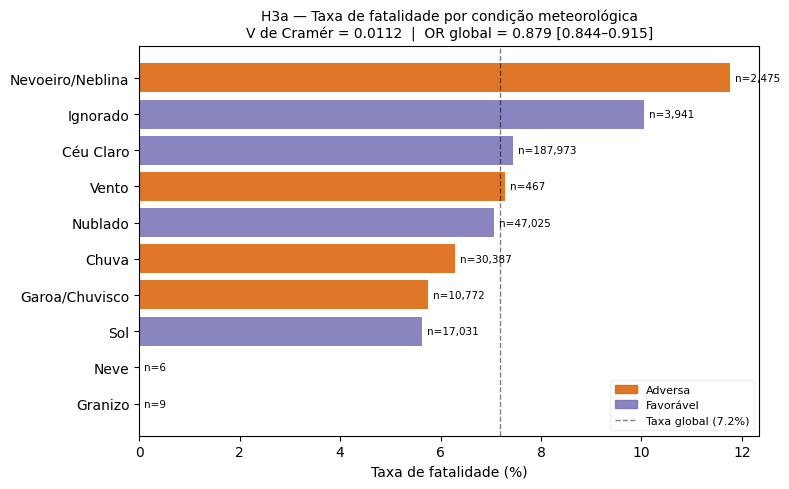

In [10]:
# Taxa de fatalidade por condição meteorológica (todas, ordenadas)
fatal_by_weather = (
    df.assign(is_fatal=df['classificacao_acidente'] == 'Com Vítimas Fatais')
    .groupby('condicao_meteorologica')
    .agg(
        taxa_fatalidade=('is_fatal', 'mean'),
        n=('is_fatal', 'count')
    )
    .sort_values('taxa_fatalidade', ascending=True)
)
fatal_by_weather['is_adverse'] = fatal_by_weather.index.isin(ADVERSE_CONDITIONS)

fig, ax = plt.subplots(figsize=(8, 5))

colors = [
    '#d95f02' if adv else '#7570b3'
    for adv in fatal_by_weather['is_adverse']
]
bars = ax.barh(
    fatal_by_weather.index,
    fatal_by_weather['taxa_fatalidade'] * 100,
    color=colors,
    alpha=0.85,
)

# Linha de referência: taxa global
global_rate = (df['classificacao_acidente'] == 'Com Vítimas Fatais').mean() * 100
ax.axvline(global_rate, color='black', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Taxa global ({global_rate:.1f}%)')

# Anotar n
for i, (idx, row) in enumerate(fatal_by_weather.iterrows()):
    ax.text(row['taxa_fatalidade'] * 100 + 0.1, i,
            f"n={row['n']:,}", va='center', fontsize=7.5)

legend_patches = [
    mpatches.Patch(color='#d95f02', alpha=0.85, label='Adversa'),
    mpatches.Patch(color='#7570b3', alpha=0.85, label='Favorável'),
]
ax.legend(handles=legend_patches + [ax.get_lines()[0]], framealpha=0.3, fontsize=8)
ax.set_xlabel('Taxa de fatalidade (%)')
ax.set_title(
    f'H3a — Taxa de fatalidade por condição meteorológica\n'
    f'V de Cramér = {result.h3a.cramers_v:.4f}  |  '
    f'OR global = {result.h3a.or_global.odds_ratio:.3f} '
    f'[{result.h3a.or_global.ci_lower:.3f}–{result.h3a.or_global.ci_upper:.3f}]',
    fontsize=10,
)
fig.tight_layout()
#plt.savefig('docs/figures/h3a_taxa_fatalidade_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. H3b — Heterogeneidade regional: forest plot dos ORs

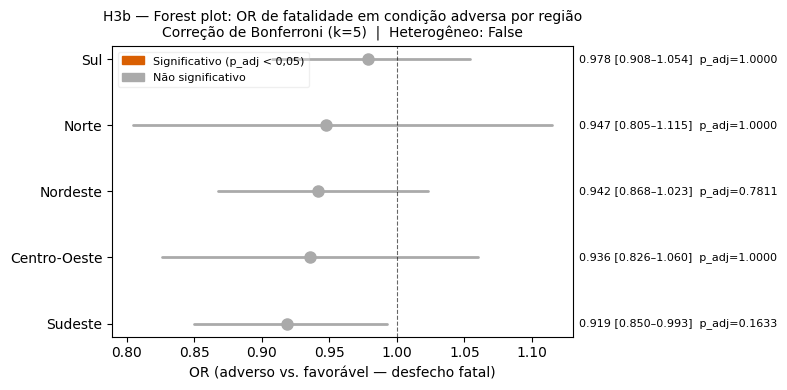

In [11]:
regional_rates = result.h3b.regional_rates.sort_values('odds_ratio', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

regions = regional_rates.index.tolist()
y_pos = np.arange(len(regions))

for i, region in enumerate(regions):
    row = regional_rates.loc[region]
    color = '#d95f02' if row['significativo'] else '#aaaaaa'
    ax.plot(
        [row['ci_lower'], row['ci_upper']], [i, i],
        color=color, linewidth=2, solid_capstyle='round'
    )
    ax.plot(row['odds_ratio'], i, 'o', color=color, markersize=8, zorder=5)

    label = (
        f"{row['odds_ratio']:.3f} [{row['ci_lower']:.3f}–{row['ci_upper']:.3f}]  "
        f"p_adj={row['p_value_bonferroni']:.4f}"
    )
    ax.text(regional_rates['ci_upper'].max() + 0.02, i, label, va='center', fontsize=8)

ax.axvline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(regions)
ax.set_xlabel('OR (adverso vs. favorável — desfecho fatal)')
ax.set_title(
    f'H3b — Forest plot: OR de fatalidade em condição adversa por região\n'
    f'Correção de Bonferroni (k={result.h3b.n_bonferroni})  |  '
    f'Heterogêneo: {result.h3b.heterogeneous}',
    fontsize=10,
)

sig_patch = mpatches.Patch(color='#d95f02', label='Significativo (p_adj < 0,05)')
ns_patch = mpatches.Patch(color='#aaaaaa', label='Não significativo')
ax.legend(handles=[sig_patch, ns_patch], framealpha=0.3, fontsize=8)

fig.tight_layout()
#plt.savefig('docs/figures/h3b_forest_plot_regional.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Heatmap: taxa de fatalidade por região × condição meteorológica

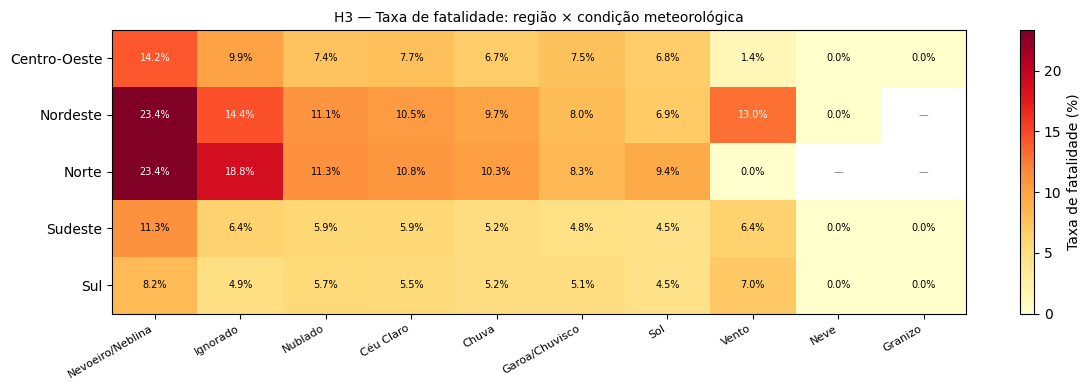

In [12]:
# Heatmap completo: região × condição meteorológica
heat = (
    df.assign(is_fatal=df['classificacao_acidente'] == 'Com Vítimas Fatais')
    .groupby(['regiao', 'condicao_meteorologica'])['is_fatal']
    .agg(['mean', 'count'])
    .reset_index()
)

# Pivot — apenas condições com n >= 30 em pelo menos uma região
pivot = heat.pivot_table(
    index='regiao',
    columns='condicao_meteorologica',
    values='mean',
    aggfunc='first'
)

# Ordenar colunas pela taxa média
col_order = pivot.mean(axis=0).sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values * 100, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(col_order, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(len(col_order)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.12 else 'black'
            ax.text(j, i, f'{val*100:.1f}%', ha='center', va='center',
                    fontsize=7, color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=7, color='gray')

plt.colorbar(im, ax=ax, label='Taxa de fatalidade (%)')
ax.set_title('H3 — Taxa de fatalidade: região × condição meteorológica', fontsize=10)
fig.tight_layout()
#plt.savefig('docs/figures/h3_heatmap_regiao_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
pivot

condicao_meteorologica,Nevoeiro/Neblina,Ignorado,Nublado,Céu Claro,Chuva,Garoa/Chuvisco,Sol,Vento,Neve,Granizo
regiao,,,,,,,,,,
Centro-Oeste,0.142259,0.098827,0.074092,0.077234,0.067317,0.075397,0.068015,0.014493,0.0,0.0
Nordeste,0.233716,0.144307,0.110582,0.105408,0.096895,0.079706,0.068618,0.130435,0.0,NaN
Norte,0.233645,0.187621,0.113407,0.108065,0.102828,0.082547,0.093874,0.000000,NaN,NaN
Sudeste,0.112652,0.063906,0.059194,0.058832,0.051908,0.048152,0.045379,0.063725,0.0,0.0
Sul,0.082107,0.049457,0.056943,0.055384,0.051520,0.051244,0.045277,0.070423,0.0,0.0


## 5. Resultado final

In [13]:
print('=' * 60)
print(result.summary)
print('=' * 60)
print(f'\nH3 confirmada: {result.confirmed}')
print(f'  Heterogeneidade regional: {result.h3b.heterogeneous}')
print()
print('Detalhamento regional:')
display(result.h3b.regional_rates[[
    'n_total', 'taxa_fatal_adverso', 'taxa_fatal_favoravel',
    'odds_ratio', 'ci_lower', 'ci_upper',
    'p_value_bonferroni', 'significativo'
]].style.format({
    'taxa_fatal_adverso': '{:.3%}',
    'taxa_fatal_favoravel': '{:.3%}',
    'odds_ratio': '{:.3f}',
    'ci_lower': '{:.3f}',
    'ci_upper': '{:.3f}',
    'p_value_bonferroni': '{:.4f}',
}))

H3 — REFUTADA

Efeito global (H3a):
  χ² = 38.6  |  V de Cramér = 0.0112  |  p = 5.21e-10
  OR = 0.879 [IC 95%: 0.844–0.915]
  Taxa de fatalidade: adverso = 6.469%  | favorável = 7.296%

Heterogeneidade regional (H3b) — correção de Bonferroni (k = 5):
  Centro-Oeste    OR = 0.936 [0.826–1.060]  p_adj = 1.0000  ✗
  Nordeste        OR = 0.942 [0.868–1.023]  p_adj = 0.7811  ✗
  Norte           OR = 0.947 [0.805–1.115]  p_adj = 1.0000  ✗
  Sudeste         OR = 0.919 [0.850–0.993]  p_adj = 0.1633  ✗
  Sul             OR = 0.978 [0.908–1.054]  p_adj = 1.0000  ✗

  Amplitude dos ORs regionais: 0.060  (homogêneo)

H3 confirmada: False
  Heterogeneidade regional: False

Detalhamento regional:


,n_total,taxa_fatal_adverso,taxa_fatal_favoravel,odds_ratio,ci_lower,ci_upper,p_value_bonferroni,significativo
regiao,,,,,,,,
Centro-Oeste,35697,7.219%,7.675%,0.936,0.826,1.060,1.0000,False
Nordeste,65480,9.851%,10.393%,0.942,0.868,1.023,0.7811,False
Norte,16175,10.551%,11.072%,0.947,0.805,1.115,1.0000,False
Sudeste,94491,5.361%,5.806%,0.919,0.850,0.993,0.1633,False
Sul,88243,5.391%,5.504%,0.978,0.908,1.054,1.0000,False


In [ ]:
df[]